## Imports

In [38]:
import pandas as pd
import numpy as np
import torch
from datasets import load_from_disk
from seqeval.metrics import f1_score, precision_score, recall_score, accuracy_score
from collections import Counter, defaultdict
from transformers import AutoTokenizer, AutoModelForTokenClassification, AutoConfig, DataCollatorForTokenClassification 
from transformers import TrainingArguments, Trainer
from transformers import EarlyStoppingCallback
from datasets import load_metric, concatenate_datasets, load_from_disk
from collections import Counter, defaultdict
import seaborn as sns
from matplotlib import pyplot as plt

## Model

In [39]:
model_name = 'deepset/gbert-base'

In [40]:
date_of_experiment = '2022_07_10'

## Tokenizer

In [41]:
tokenizer = AutoTokenizer.from_pretrained(model_name) # more params defined in method tokenize_and_align_labels()

## Data collator

In [42]:
data_collator = DataCollatorForTokenClassification(tokenizer)

## Training params

In [43]:
NUM_EPOCHS = 10
BATCH_SIZE = 4
LOGGING_STRATEGY='epoch'
OUTPUT_DIR = f'../../../../../models/{model_name}-sm_tg_sequential-{NUM_EPOCHS}_epochs_{date_of_experiment}'
OVERWRITE_OUTPUT_DIR = True
LOG_LEVEL = 'error'
EVALUATION_STRATEGY = 'epoch'
SAVE_STRATEGY ='epoch'
WEIGHT_DECAY = 0.01 # The weight decay to apply (if not zero) to all layers except all bias and LayerNorm weights in AdamW optimizer.
CALLBACK = EarlyStoppingCallback(early_stopping_patience=3)
LOAD_BEST_MODEL_AT_END = True,
METRIC_FOR_BEST_MODEL='eval_loss'

## Check GPU and set up torch device

In [44]:
# check gpu
torch.cuda.is_available()

True

In [45]:
# create torch device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## Load and prepare data

### Combine Smartdata and Telegram train splits to create training data

In [46]:
smartdata = load_from_disk('/home/eli/data/data_prepared_for_tf/smartdata/')
telegram = load_from_disk('/home/eli/data/data_prepared_for_tf/telegram_train_test_valid/')
assert smartdata['train'].features == telegram['train'].features
assert smartdata['test'].features == telegram['test'].features
assert smartdata['validation'].features == telegram['validation'].features

### Shuffle training data from smartdata and Telegram

In [47]:
smartdata['train'] = smartdata['train'].shuffle(seed=42)

Loading cached shuffled indices for dataset at /home/eli/data/data_prepared_for_tf/smartdata/train/cache-1e30bce2286527d9.arrow


In [48]:
telegram['train'] = telegram['train'].shuffle(seed=42)

Loading cached shuffled indices for dataset at /home/eli/data/data_prepared_for_tf/telegram_train_test_valid/train/cache-587130ce937ed5b0.arrow


### Methods for processing

In [49]:
def get_indices_and_tags(ds, tag_name='ner_tags'):
    tags = ds.features[tag_name].feature
    #id2label param for model
    index2tag = {idx: tag for idx, tag in enumerate(tags.names)}
    # label2id param for model
    tag2index = {tag: idx for idx, tag in enumerate(tags.names)}
    
    return tags, index2tag, tag2index


def tokenize_and_align_labels(examples):
    
    tokenized_inputs = tokenizer(
        examples['tokens'], 
        padding='max_length',
        truncation=True, 
        is_split_into_words=True
    )    
    
    labels = []
    
    for idx, label in enumerate(examples['ner_tags']):
        word_ids = tokenized_inputs.word_ids(batch_index=idx)
        previous_word_idx = None
        label_ids = []
        for word_idx in word_ids:
            if word_idx is None or word_idx == previous_word_idx:
                label_ids.append(-100)
            else: 
                label_ids.append(label[word_idx])
            previous_word_idx = word_idx
        labels.append(label_ids)
    tokenized_inputs['labels'] = labels
    return tokenized_inputs


def encode_dataset(corpus, columns_to_remove=['ner_tags', 'tokens', 'ner_tags_str']):
    return corpus.map(tokenize_and_align_labels, 
                      batched=True,
                      remove_columns=columns_to_remove)

### Methods for evaluation

In [50]:
def align_predictions(predictions, label_ids):
    preds = np.argmax(predictions, axis=2)
    batch_size, seq_len = preds.shape
    labels_list, preds_list = [], []
    
    for batch_idx in range(batch_size):
        example_labels, example_preds = [], []
        
        for seq_idx in range(seq_len):
            # Ignore label IDs = -100
            if label_ids[batch_idx, seq_idx] != -100:
                example_labels.append(index2tag[label_ids[batch_idx][seq_idx]])
                example_preds.append(index2tag[preds[batch_idx][seq_idx]])
        labels_list.append(example_labels)
        preds_list.append(example_preds)
        
    return preds_list, labels_list    


def compute_metrics(eval_pred):
    y_pred, y_true = align_predictions(eval_pred.predictions, 
                                       eval_pred.label_ids)
    
    f1 = f1_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    accuracy = accuracy_score(y_true, y_pred)
    
    return {'f1': f1, 
            'precision': precision,
            'recall': recall,
            'accuracy': accuracy}


def get_training_history(trainer):
    df = pd.DataFrame(trainer.state.log_history)[['epoch','loss' ,'eval_loss', 'eval_f1', 'eval_precision', 'eval_recall', 'eval_accuracy']]
    df = df.rename(columns={"epoch":"epoch",
                            "loss": "training_loss", 
                            "eval_loss": "validation_loss", 
                            "eval_f1":"f1", 
                            "eval_precision": "precision",
                           'eval_recall': 'recall', 
                            'eval_accuracy': 'accuracy'})
    df['epoch'] = df["epoch"].apply(lambda x: round(x))
    df['training_loss'] = df["training_loss"].ffill()
    df[['validation_loss', 'f1']] = df[['validation_loss', 'f1']].bfill().ffill()
    df.drop_duplicates()
    
    return df

In [51]:
tags, index2tag, tag2index = get_indices_and_tags(smartdata['train'])

In [52]:
sm_train_encoded = encode_dataset(smartdata['train'])

Loading cached processed dataset at /home/eli/data/data_prepared_for_tf/smartdata/train/cache-1c80317fa3b1799d.arrow


In [53]:
sm_eval_encoded = encode_dataset(smartdata['validation'])

Loading cached processed dataset at /home/eli/data/data_prepared_for_tf/smartdata/validation/cache-bdd640fb06671ad1.arrow


## model initialization and config

In [54]:
model_config = AutoConfig.from_pretrained(model_name, 
                                        num_labels=sm_tags.num_classes, 
                                        id2label=sm_index2tag,
                                        label2id=sm_tag2index)

In [55]:
model = AutoModelForTokenClassification.from_pretrained(model_name, config=model_config)

## Training

In [56]:
training_args = TrainingArguments(
    output_dir=OUTPUT_DIR, 
    overwrite_output_dir=OVERWRITE_OUTPUT_DIR, 
    log_level=LOG_LEVEL, 
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE, 
    evaluation_strategy=EVALUATION_STRATEGY,
    save_strategy=SAVE_STRATEGY,
    weight_decay=WEIGHT_DECAY,
    logging_strategy=LOGGING_STRATEGY,
    disable_tqdm=False,
    load_best_model_at_end=LOAD_BEST_MODEL_AT_END,
    metric_for_best_model=METRIC_FOR_BEST_MODEL)

In [57]:
trainer = Trainer(
    model=model, 
    args=training_args,
    data_collator=data_collator, 
    compute_metrics=compute_metrics,
    train_dataset=sm_train_encoded,
    eval_dataset=sm_eval_encoded,
    tokenizer=tokenizer,
    callbacks=[CALLBACK])

In [58]:
%time
trainer.train()

CPU times: user 2 µs, sys: 0 ns, total: 2 µs
Wall time: 5.72 µs


Epoch,Training Loss,Validation Loss,F1,Precision,Recall,Accuracy
1,0.201000,0.249924,0.748463,0.741828,0.755217,0.941944
2,0.093300,0.268145,0.777746,0.782857,0.772702,0.946573
3,0.063800,0.277407,0.781268,0.776910,0.785674,0.947152
4,0.040500,0.308247,0.783493,0.785269,0.781726,0.947795


TrainOutput(global_step=1864, training_loss=0.09964161881049816, metrics={'train_runtime': 235.9224, 'train_samples_per_second': 78.882, 'train_steps_per_second': 19.752, 'total_flos': 1945286497284096.0, 'train_loss': 0.09964161881049816, 'epoch': 4.0})

In [59]:
trainer.evaluate()

{'eval_loss': 0.24992360174655914,
 'eval_f1': 0.7484628283957517,
 'eval_precision': 0.7418282548476455,
 'eval_recall': 0.7552171460800903,
 'eval_accuracy': 0.941944194419442,
 'eval_runtime': 2.6295,
 'eval_samples_per_second': 105.724,
 'eval_steps_per_second': 26.621,
 'epoch': 4.0}

In [60]:
eval_df = get_training_history(trainer)

In [61]:
eval_df

,epoch,training_loss,validation_loss,f1,precision,recall,accuracy
0,1,0.2010,0.249924,0.748463,NaN,NaN,NaN
1,1,0.2010,0.249924,0.748463,0.741828,0.755217,0.941944
2,2,0.0933,0.268145,0.777746,NaN,NaN,NaN
3,2,0.0933,0.268145,0.777746,0.782857,0.772702,0.946573
4,3,0.0638,0.277407,0.781268,NaN,NaN,NaN
5,3,0.0638,0.277407,0.781268,0.776910,0.785674,0.947152
6,4,0.0405,0.308247,0.783493,NaN,NaN,NaN
7,4,0.0405,0.308247,0.783493,0.785269,0.781726,0.947795
8,4,0.0405,0.249924,0.748463,NaN,NaN,NaN
9,4,0.0405,0.249924,0.748463,0.741828,0.755217,0.941944


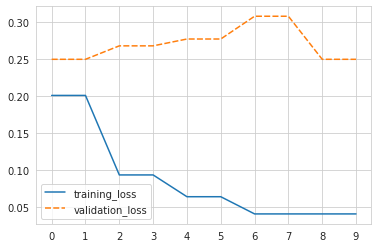

In [62]:
sns.set_style("whitegrid")
ax = sns.lineplot(data = eval_df[['training_loss', 'validation_loss']])
ax.set_xticks(range(len(eval_df)), labels=range(len(eval_df)))
plt.show()

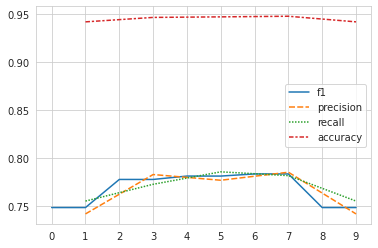

In [63]:
sns.set_style("whitegrid")
ax = sns.lineplot(data = eval_df[['f1', 'precision', 'recall', 'accuracy']])
ax.set_xticks(range(len(eval_df)), labels=range(len(eval_df)))
plt.show()

In [64]:
trainer.create_model_card()

## Error Analysis

In [92]:
from torch.nn.functional import cross_entropy

In [93]:
num_labels = 13

def forward_pass_with_label(batch):
    # Convert dict of lists to list of dicts suitable for data collator
    features = [dict(zip(batch, t)) for t in zip(*batch.values())]
    # Pad inputs and labels and put all tensors on device
    batch = data_collator(features)
    input_ids = batch["input_ids"].to(device)
    attention_mask = batch["attention_mask"].to(device)
    labels = batch["labels"].to(device)
    with torch.no_grad():
        # Pass data through model  
        output = trainer.model(input_ids, attention_mask)
        # Logit.size: [batch_size, sequence_length, classes]
        # Predict class with largest logit value on classes axis
        predicted_label = torch.argmax(output.logits, axis=-1).cpu().numpy()
    # Calculate loss per token after flattening batch dimension with view
    loss = cross_entropy(output.logits.view(-1, num_labels), 
                         labels.view(-1), reduction="none")
    # Unflatten batch dimension and convert to numpy array
    loss = loss.view(len(input_ids), -1).cpu().numpy()

    return {"loss":loss, "predicted_label": predicted_label}

In [105]:
val_set_sm = sm_eval_encoded
val_set_sm = val_set_sm.map(forward_pass_with_label, batched=True, batch_size=32)
df = val_set_sm.to_pandas()

100%|█████████████████████████████████████████████| 9/9 [00:02<00:00,  3.99ba/s]


In [106]:
df.head()

,input_ids,token_type_ids,attention_mask,labels,loss,predicted_label
0,"[102, 12052, 30886, 6357, 853, 201, 1270, 2530...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[-100, 0, -100, 0, 0, 0, 3, 0, 0, -100, 0, 0, ...","[0.0, 0.004426562, 0.0, 0.0022144814, 0.001629...","[0, 0, 0, 0, 0, 0, 3, 0, 0, 0, 0, 0, 1, 2, 2, ..."
1,"[102, 5901, 683, 3086, 422, 30901, 232, 29794,...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[-100, 0, 0, 0, -100, -100, 0, 0, 0, 0, 0, 0, ...","[0.0, 0.00066317973, 0.0004606378, 0.021703824...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 4, ..."
2,"[102, 178, 7369, 232, 23981, 30886, 478, 4097,...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[-100, 0, -100, 0, 0, -100, 0, 0, 3, 0, 0, 0, ...","[0.0, 0.075321935, 0.0, 0.03364865, 0.02152311...","[0, 0, 0, 0, 0, 0, 0, 3, 4, 0, 0, 0, 0, 0, 0, ..."
3,"[102, 1799, 3512, 4001, 23847, 370, 218, 22646...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[-100, 0, -100, -100, -100, -100, 5, -100, 0, ...","[0.0, 0.10735917, 0.0, 0.0, 0.0, 0.0, 0.059934...","[0, 0, 0, 0, 0, 0, 5, 6, 0, 0, 0, 0, 5, 0, 0, ..."
4,"[102, 11085, 4245, 1582, 212, 16170, 26311, 54...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[-100, 5, -100, 0, 0, 0, -100, 0, 0, 0, -100, ...","[0.0, 0.022372006, 0.0, 0.008754445, 0.0009426...","[0, 5, 6, 0, 0, 0, 0, 0, 0, 0, 0, 1, 2, 2, 2, ..."


In [107]:
index2tag[-100] = "IGN"
df["input_tokens"] = df["input_ids"].apply(
    lambda x: tokenizer.convert_ids_to_tokens(x))
df["predicted_label"] = df["predicted_label"].apply(
    lambda x: [index2tag[i] for i in x])
df["labels"] = df["labels"].apply(
    lambda x: [index2tag[i] for i in x])
df['loss'] = df.apply(
    lambda x: x['loss'][:len(x['input_ids'])], axis=1)
df['predicted_label'] = df.apply(
    lambda x: x['predicted_label'][:len(x['input_ids'])], axis=1)
df.head(1)

,input_ids,token_type_ids,attention_mask,labels,loss,predicted_label,input_tokens
0,"[102, 12052, 30886, 6357, 853, 201, 1270, 2530...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[IGN, O, IGN, O, O, O, B-LOC, O, O, IGN, O, O,...","[0.0, 0.004426562, 0.0, 0.0022144814, 0.001629...","[O, O, O, O, O, O, B-LOC, O, O, O, O, O, B-DAT...","[[CLS], Sonstige, ##s, Abschnitt, :, (, Berlin..."


In [108]:
df_tokens = df.apply(pd.Series.explode)
df_tokens = df_tokens.query("labels != 'IGN'")
df_tokens["loss"] = df_tokens["loss"].astype(float).round(2)
df_tokens.head(7)

,input_ids,token_type_ids,attention_mask,labels,loss,predicted_label,input_tokens
0,12052,0,1,O,0.00,O,Sonstige
0,6357,0,1,O,0.00,O,Abschnitt
0,853,0,1,O,0.00,O,:
0,201,0,1,O,0.00,O,(
0,1270,0,1,B-LOC,0.01,B-LOC,Berlin
0,2530,0,1,O,0.02,O,)
0,15808,0,1,O,0.00,O,Gül


In [109]:
(
    df_tokens.groupby("input_tokens")[["loss"]]
    .agg(["count", "mean", "sum"])
    .droplevel(level=0, axis=1)  # Get rid of multi-level columns
    .sort_values(by="sum", ascending=False)
    .reset_index()
    .round(2)
    .head(10)
    .T
)

,0,1,2,3,4,5,6,7,8,9
input_tokens,.,-,#,@,",",Uhr,Protest,Kund,:,(
count,647,351,110,150,402,64,6,4,262,112
mean,0.19,0.28,0.72,0.33,0.11,0.63,5.45,8.09,0.12,0.28
sum,121.91,98.12,79.04,50.14,43.77,40.26,32.73,32.36,31.64,31.27


### Observations
TODO

In [110]:
(
    df_tokens.groupby("labels")[["loss"]] 
    .agg(["count", "mean", "sum"])
    .droplevel(level=0, axis=1)
    .sort_values(by="mean", ascending=False)
    .reset_index()
    .round(2)
    .T
)

,0,1,2,3,4,5,6,7,8,9,10,11,12
labels,I-ACTION,B-ACTION,B-TIME,I-ORG,I-LOC,B-ORG,I-TIME,I-PER,B-PER,I-DATE,B-LOC,B-DATE,O
count,6,47,95,251,315,416,61,127,142,166,852,214,12862
mean,10.95,10.64,1.3,1.27,0.76,0.71,0.7,0.65,0.6,0.5,0.49,0.47,0.08
sum,65.7,500.22,123.75,318.44,240.22,296.02,42.46,82.36,85.32,83.56,420.59,101.29,976.03


### Observations
TODO

In [111]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

def plot_confusion_matrix(y_true, y_preds, labels):
    cm = confusion_matrix(y_true, y_preds, normalize="true")
    fig, ax = plt.subplots(figsize=(10, 10))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(cmap="Blues", values_format=".2f", ax=ax, colorbar=False)
    plt.title("Normalized confusion matrix")
    plt.show()

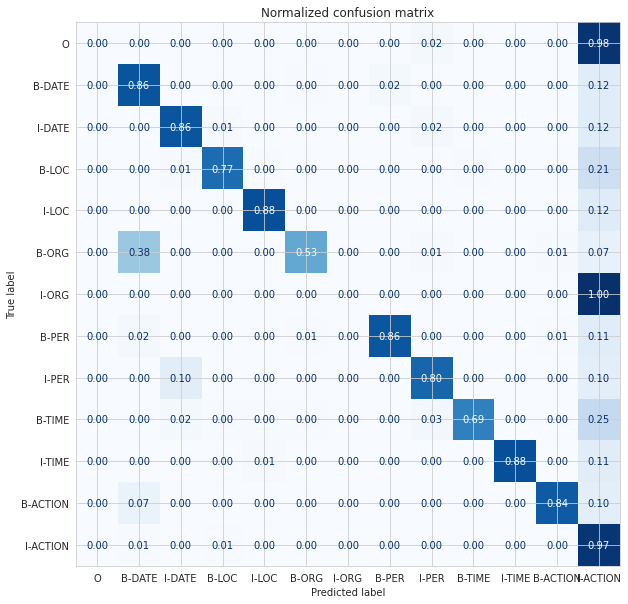

In [112]:
plot_confusion_matrix( df_tokens["labels"], df_tokens["predicted_label"],
                      tags.names)

In [113]:
def get_samples(df):
    for _, row in df.iterrows():
        labels, preds, tokens, losses = [], [], [], []
        for i, mask in enumerate(row["attention_mask"]):
            if i not in {0, len(row["attention_mask"])}:
                labels.append(row["labels"][i])
                preds.append(row["predicted_label"][i])
                tokens.append(row["input_tokens"][i])
                losses.append(f"{row['loss'][i]:.2f}")
        df_tmp = pd.DataFrame({"tokens": tokens, "labels": labels, 
                               "preds": preds, "losses": losses}).T
        yield df_tmp

df["total_loss"] = df["loss"].apply(sum)
df_tmp = df.sort_values(by="total_loss", ascending=False).head(3)

for sample in get_samples(df_tmp):
    display(sample)

,0,1,2,3,4,5,6,7,8,9,...,501,502,503,504,505,506,507,508,509,510
tokens,06,.,09,.,T,##ER,##M,##INE,B,##UND,...,[PAD],[PAD],[PAD],[PAD],[PAD],[PAD],[PAD],[PAD],[PAD],[PAD]
labels,B-DATE,IGN,IGN,IGN,O,IGN,IGN,IGN,O,IGN,...,IGN,IGN,IGN,IGN,IGN,IGN,IGN,IGN,IGN,IGN
preds,B-DATE,I-DATE,I-DATE,I-DATE,O,O,O,O,O,O,...,O,O,O,O,O,O,O,O,O,O
losses,0.03,0.00,0.00,0.00,0.19,0.00,0.00,0.00,0.07,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


,0,1,2,3,4,5,6,7,8,9,...,501,502,503,504,505,506,507,508,509,510
tokens,Teil,2,-,Übersicht,(,Stand,09,.,11,.,...,[PAD],[PAD],[PAD],[PAD],[PAD],[PAD],[PAD],[PAD],[PAD],[PAD]
labels,O,O,O,O,O,O,B-DATE,IGN,IGN,IGN,...,IGN,IGN,IGN,IGN,IGN,IGN,IGN,IGN,IGN,IGN
preds,O,O,O,O,O,O,B-DATE,I-DATE,I-DATE,I-DATE,...,O,O,O,O,O,O,O,O,O,O
losses,0.02,0.01,0.00,0.00,0.00,0.00,0.02,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


,0,1,2,3,4,5,6,7,8,9,...,501,502,503,504,505,506,507,508,509,510
tokens,Demo,-,Termine,von,https,:,/,/,ter,##min,...,[PAD],[PAD],[PAD],[PAD],[PAD],[PAD],[PAD],[PAD],[PAD],[PAD]
labels,O,IGN,IGN,O,O,IGN,IGN,IGN,IGN,IGN,...,IGN,IGN,IGN,IGN,IGN,IGN,IGN,IGN,IGN,IGN
preds,O,O,O,O,O,O,O,O,O,O,...,O,O,O,O,O,O,O,O,O,O
losses,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


In [114]:
df_tmp = df.loc[df["input_tokens"].apply(lambda x: ")" in x)].head()
for sample in get_samples(df_tmp):
    display(sample)

,0,1,2,3,4,5,6,7,8,9,...,501,502,503,504,505,506,507,508,509,510
tokens,Sonstige,##s,Abschnitt,:,(,Berlin,),Gül,##tig,ab,...,[PAD],[PAD],[PAD],[PAD],[PAD],[PAD],[PAD],[PAD],[PAD],[PAD]
labels,O,IGN,O,O,O,B-LOC,O,O,IGN,O,...,IGN,IGN,IGN,IGN,IGN,IGN,IGN,IGN,IGN,IGN
preds,O,O,O,O,O,B-LOC,O,O,O,O,...,O,O,O,O,O,O,O,O,O,O
losses,0.00,0.00,0.00,0.00,0.00,0.01,0.02,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


,0,1,2,3,4,5,6,7,8,9,...,501,502,503,504,505,506,507,508,509,510
tokens,Wegen,eines,Not,##art,##z,-,Einsatzes,ist,derzeit,die,...,[PAD],[PAD],[PAD],[PAD],[PAD],[PAD],[PAD],[PAD],[PAD],[PAD]
labels,O,O,O,IGN,IGN,O,O,O,O,O,...,IGN,IGN,IGN,IGN,IGN,IGN,IGN,IGN,IGN,IGN
preds,O,O,O,O,O,O,O,O,O,O,...,O,O,I-TIME,I-TIME,O,O,O,O,O,O
losses,0.00,0.00,0.02,0.00,0.00,0.00,0.00,0.00,0.05,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


,0,1,2,3,4,5,6,7,8,9,...,501,502,503,504,505,506,507,508,509,510
tokens,R,##SS,-,Feed,##s,Im,Süden,Japans,hat,es,...,[PAD],[PAD],[PAD],[PAD],[PAD],[PAD],[PAD],[PAD],[PAD],[PAD]
labels,O,IGN,O,O,IGN,O,O,B-LOC,O,O,...,IGN,IGN,IGN,IGN,IGN,IGN,IGN,IGN,IGN,IGN
preds,O,O,O,O,O,O,B-LOC,I-LOC,O,O,...,O,O,O,O,O,O,O,O,O,O
losses,0.08,0.00,0.03,0.02,0.00,0.00,1.67,2.44,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


,0,1,2,3,4,5,6,7,8,9,...,501,502,503,504,505,506,507,508,509,510
tokens,Flug,##beg,##leiter,##gewerk,##schaft,U,##FO,weite,##t,Streik,...,[PAD],[PAD],[PAD],[PAD],[PAD],[PAD],[PAD],[PAD],[PAD],[PAD]
labels,O,IGN,IGN,IGN,IGN,B-ORG,IGN,O,IGN,O,...,IGN,IGN,IGN,IGN,IGN,IGN,IGN,IGN,IGN,IGN
preds,O,O,O,O,O,B-ORG,I-ORG,O,O,O,...,O,O,O,O,O,O,O,O,O,O
losses,0.11,0.00,0.00,0.00,0.00,0.06,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


,0,1,2,3,4,5,6,7,8,9,...,501,502,503,504,505,506,507,508,509,510
tokens,Fan,##uc,kommt,mit,glän,##zenden,Zahlen,zur,Automat,##ica,...,[PAD],[PAD],[PAD],[PAD],[PAD],[PAD],[PAD],[PAD],[PAD],[PAD]
labels,B-ORG,IGN,O,O,O,IGN,O,O,O,IGN,...,IGN,IGN,IGN,IGN,IGN,IGN,IGN,IGN,IGN,IGN
preds,B-ORG,I-ORG,O,O,O,O,O,O,O,O,...,O,O,O,O,O,O,O,O,O,O
losses,0.02,0.00,0.01,0.00,0.00,0.00,0.00,0.00,0.08,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


In [115]:
df.columns

Index(['input_ids', 'token_type_ids', 'attention_mask', 'labels', 'loss',
       'predicted_label', 'input_tokens', 'total_loss'],
      dtype='object')

In [116]:
df_tmp = df.loc[df["predicted_label"].apply(lambda x: "I-ACTION" in x)].head()
for sample in get_samples(df_tmp):
    display(sample)

In [117]:
index2tag[-100] = "IGN"
df["input_tokens"] = df["input_ids"].apply(
    lambda x: tokenizer.convert_ids_to_tokens(x))
df["predicted_label"] = df["predicted_label"].apply(
    lambda x: [index2tag[i] for i in x])
df["labels"] = df["labels"].apply(
    lambda x: [index2tag[i] for i in x])
df['loss'] = df.apply(
    lambda x: x['loss'][:len(x['input_ids'])], axis=1)
df['predicted_label'] = df.apply(
    lambda x: x['predicted_label'][:len(x['input_ids'])], axis=1)
df.head(1)

KeyError: 'O'